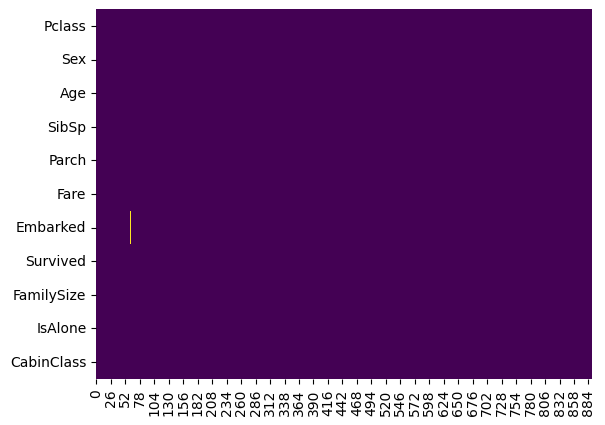

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Load data
df = pd.read_csv('train.csv')

# Keep useful features (you can adjust these)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Cabin']
target = 'Survived'

# Drop rows with missing values (TabPFN doesn't handle NaNs)
df = df[features + [target]]
df['Age'] = df['Age'].fillna(df['Age'].median())  # Fill missing Age with median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())  # Fill missing Fare with median

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['CabinClass'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')  # Extract first letter of Cabin
df.drop(columns=['Cabin'], inplace=True)  # Drop columns not needed
df.dropna()  # Drop rows where Embarked is NaN

sns.heatmap(df.isna().T, cbar=False, cmap='viridis')
# Encode categorical features
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])
df['CabinClass'] = LabelEncoder().fit_transform(df['CabinClass']) 

scaler = StandardScaler()
X = scaler.fit_transform(df)

# Features and target
X = df.drop(columns=[target])
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from tabpfn import TabPFNClassifier
import torch
from sklearn.metrics import classification_report

# Initialize TabPFN
clf = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')

# Fit and predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/tabpfn/classifier.py:432: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(


              precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



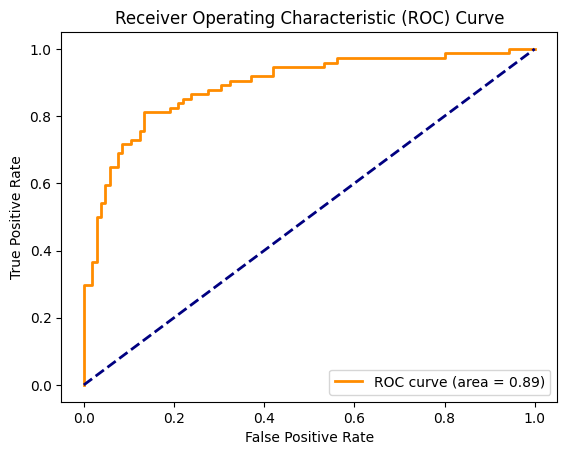

In [53]:
from sklearn.metrics import roc_curve, auc

# Get the probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [72]:
submission_df = pd.read_csv("test.csv")
passenger = submission_df['PassengerId']
submission_df['FamilySize'] = submission_df['SibSp'] + submission_df['Parch'] + 1
submission_df['IsAlone'] = (submission_df['FamilySize'] == 1).astype(int)
submission_df['CabinClass'] = submission_df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')  # Extract first letter of Cabin
submission_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)  # Drop columns not needed

submission_df['Sex'] = LabelEncoder().fit_transform(submission_df['Sex'])
submission_df['Embarked'] = LabelEncoder().fit_transform(submission_df['Embarked'])
submission_df['CabinClass'] = LabelEncoder().fit_transform(submission_df['CabinClass']) 
# submission_df['Age'] = submission_df['Age'].fillna(submission_df['Age'].median())  # Fill missing Age with median
# submission_df['Fare'] = submission_df['Fare'].fillna(submission_df['Fare'].median())  # Fill missing Fare with median

preds = clf.predict(submission_df)
output = pd.DataFrame({
    "PassengerId": passenger,
    "Survived": preds
})
output.to_csv("submission_PFN.csv", index=False)

<Axes: >

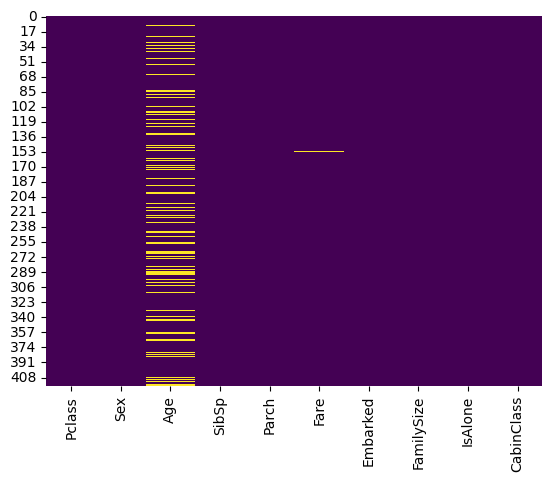

In [73]:
sns.heatmap(submission_df.isna(), cbar=False, cmap='viridis')

In [ ]:
# Convert to PyTorch tensors
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create datasets and loaders
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [63]:
import torch.nn as nn
import torch.nn.functional as F

class TitanicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return torch.sigmoid(self.out(x))  # sigmoid for binary classification

In [64]:
model = TitanicNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 4000
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

Epoch 1/4000 - Loss: 14.8011
Epoch 2/4000 - Loss: 14.7210
Epoch 3/4000 - Loss: 13.5985
Epoch 4/4000 - Loss: 13.4821
Epoch 5/4000 - Loss: 13.3160
Epoch 6/4000 - Loss: 13.6960
Epoch 7/4000 - Loss: 12.9252
Epoch 8/4000 - Loss: 13.6582
Epoch 9/4000 - Loss: 14.0601
Epoch 10/4000 - Loss: 13.1606
Epoch 11/4000 - Loss: 12.7402
Epoch 12/4000 - Loss: 12.4782
Epoch 13/4000 - Loss: 12.2737
Epoch 14/4000 - Loss: 12.3782
Epoch 15/4000 - Loss: 12.2267
Epoch 16/4000 - Loss: 11.7905
Epoch 17/4000 - Loss: 11.5560
Epoch 18/4000 - Loss: 11.4840
Epoch 19/4000 - Loss: 11.5205
Epoch 20/4000 - Loss: 12.1004
Epoch 21/4000 - Loss: 11.2501
Epoch 22/4000 - Loss: 11.0917
Epoch 23/4000 - Loss: 10.9212
Epoch 24/4000 - Loss: 10.6201
Epoch 25/4000 - Loss: 10.9273
Epoch 26/4000 - Loss: 10.5509
Epoch 27/4000 - Loss: 10.8591
Epoch 28/4000 - Loss: 10.5377
Epoch 29/4000 - Loss: 10.4205
Epoch 30/4000 - Loss: 10.7066
Epoch 31/4000 - Loss: 10.5501
Epoch 32/4000 - Loss: 9.9377
Epoch 33/4000 - Loss: 10.3236
Epoch 34/4000 - Loss

In [65]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    predicted_labels = (preds > 0.5).float()

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test_tensor, predicted_labels))
print("AUC:", roc_auc_score(y_test_tensor, preds))
print("Classification Report:\n", classification_report(y_test_tensor, predicted_labels))

Accuracy: 0.7932960893854749
AUC: 0.7973616473616474
Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       105
         1.0       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [74]:
submission_df = pd.read_csv("test.csv")
passenger = submission_df['PassengerId']
submission_df['FamilySize'] = submission_df['SibSp'] + submission_df['Parch'] + 1
submission_df['IsAlone'] = (submission_df['FamilySize'] == 1).astype(int)
submission_df['CabinClass'] = submission_df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')  # Extract first letter of Cabin
submission_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)  # Drop columns not needed

submission_df['Sex'] = LabelEncoder().fit_transform(submission_df['Sex'])
submission_df['Embarked'] = LabelEncoder().fit_transform(submission_df['Embarked'])
submission_df['CabinClass'] = LabelEncoder().fit_transform(submission_df['CabinClass']) 

# Fill missing values
submission_df['Age'] = submission_df['Age'].fillna(submission_df['Age'].median())
submission_df['Fare'] = submission_df['Fare'].fillna(submission_df['Fare'].median())

# Scale the data
submission_scaled = scaler.transform(submission_df)

# Convert to PyTorch tensor
submission_tensor = torch.tensor(submission_scaled, dtype=torch.float32)

# Predict using the trained neural network
model.eval()
with torch.no_grad():
    preds = model(submission_tensor)
    predicted_labels = (preds > 0.5).int().squeeze()

# Create the submission file
output = pd.DataFrame({
    "PassengerId": passenger,
    "Survived": predicted_labels.numpy()
})
output.to_csv("submission_NN.csv", index=False)